(sec:vib_spect)=
# Vibrational spectroscopies

VeloxChem provides simulations of vibrational spectroscopies by evaluating molecular force constants and deriving normal modes whose frequencies and transition properties form the basis for IR and Raman spectra. Building on a converged ground‑state DFT reference, the program computes the molecular Hessian and transforms it to mass‑weighted internal coordinates to obtain physically meaningful vibrational modes, while subsequent response‑theory evaluations yield dipole‑derivative and polarizability‑derivative quantities that determine vibrational intensities. Together, these capabilities enable predictions of both harmonic vibrational frequencies and their associated infrared and Raman signatures.

The calculation of normal modes is performed with the aid of [geomeTRIC](https://pypi.org/project/geometric/).

:::{note}
It is recommended to [optimize the structure](#sec:GS-opt) before performing IR or Raman calculations.
:::

(sec:ir)=
## Infrared

Infrared (IR) spectroscopy in VeloxChem is based on the calculation of harmonic vibrational frequencies and their dipole‑moment derivatives, which determine the intensity of each normal‑mode transition. Starting from a ground state DFT reference, the molecular Hessian is evaluated and transformed into mass‑weighted normal modes, whose frequencies and IR intensities together form the vibrational spectrum.  See [visualisation of normal modes](#sec:vib-vis) and [visualisation of spectra](#sec:vib_spect) for interactive visualisation tools.

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("formaldehyde")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = True

vib_results = vib_drv.compute(molecule, basis)

Reading formaldehyde from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct I

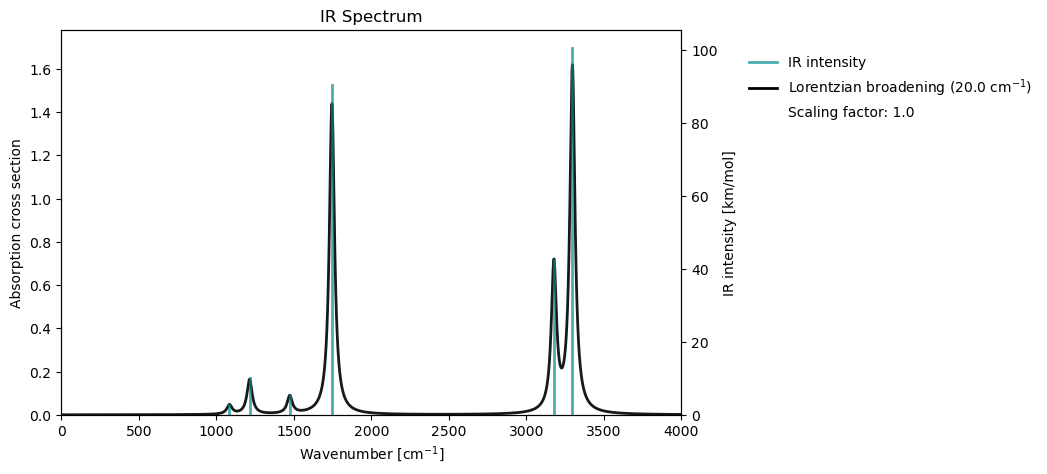

In [2]:
vib_drv.plot_ir(vib_results)

**Text file**

```
@jobs
task: vibrational
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@vibrational
do_ir: yes
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...                     
@end
```

(sec:raman)=
## Raman

Raman spectroscopy in VeloxChem is based on evaluating harmonic vibrational frequencies together with the derivatives of the molecular polarizability tensor, which determine the Raman scattering strength of each normal mode. Using the Hessian, the normal modes are obtained in their mass‑weighted form and used to compute Raman intensities from the corresponding polarizability changes. This framework enables prediction of Raman‑active vibrational features and provides a complementary perspective to IR spectroscopy through polarizability‑based selection rules.

**Python script**

In [3]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("formaldehyde")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = False
vib_drv.do_raman = True

vib_results = vib_drv.compute(molecule, basis)

Reading formaldehyde from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct I

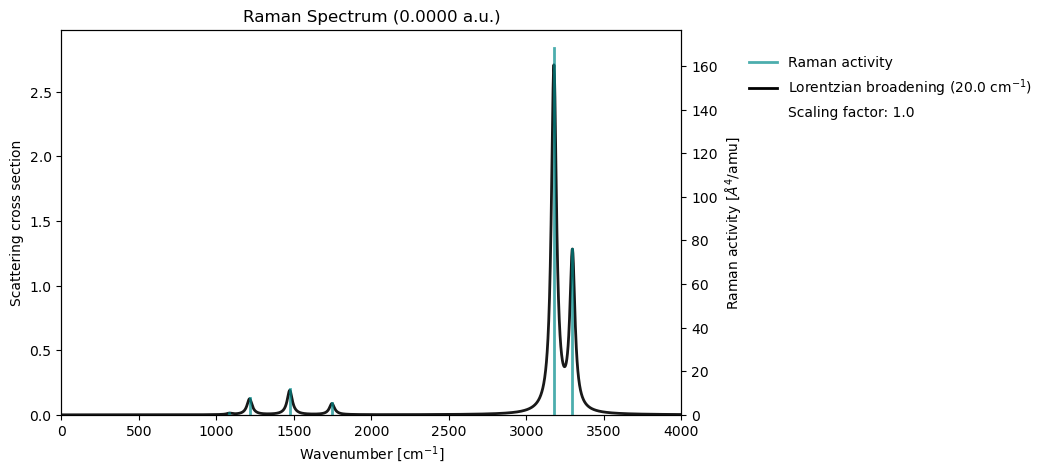

In [4]:
vib_drv.plot_raman(vib_results)

**Text file**

```
@jobs
task: vibrational
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@vibrational
do_raman: yes
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...                     
@end
```

(sec:rrs)=
## Resonance Raman

In resonance Raman spectroscopy, the vibrational intensities are selectively amplified when the excitation frequency is tuned close to an allowed electronic transition; in practice, we are often concerned with the spectrum at the transition energy of the first excited state (S$_1$).

VeloxChem implements resonance Raman spectroscopy based on geometric derivatives of the [complex polarizability](#sec:res-region). For further details on this approach, see {cite}`saidi_2014`.

In [5]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("formaldehyde")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 5
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

Reading formaldehyde from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct I

In [6]:
molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
print(f"S1 excitation energy: {rsp_results["eigenvalues"][0]:10.6f} (a.u.)")

S1 excitation energy:   0.141911 (a.u.)


**Python script**

In [8]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_name("formaldehyde")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = False
vib_drv.do_raman = False
vib_drv.do_resonance_raman = True

vib_drv.frequencies = [0.141911]

vib_results = vib_drv.compute(molecule, basis)

Reading formaldehyde from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct I

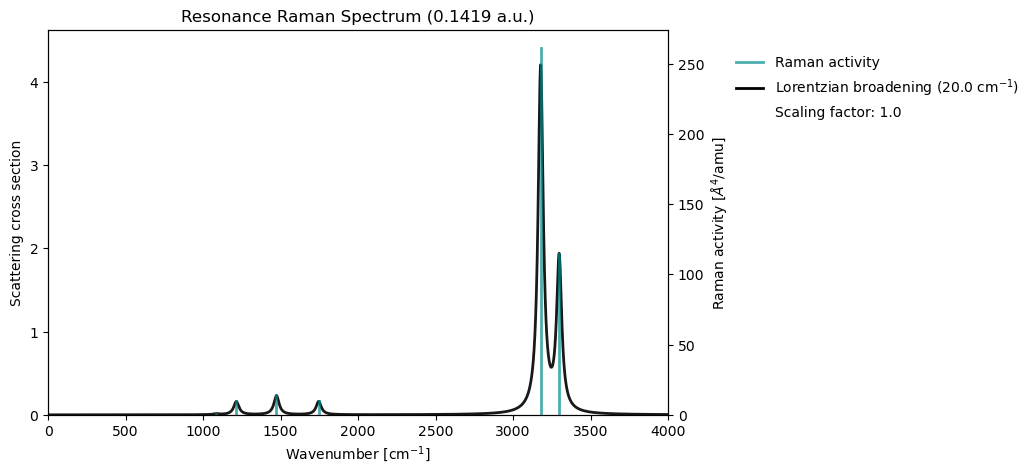

In [9]:
vib_drv.plot_raman(vib_results)

**Text file**

:::{code}
@jobs
task: vibrational
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@vibrational
do_resonance_raman: yes
frequencies: 0.05-0.10 (0.05)
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...                      
@end
:::